In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순회귀 모델

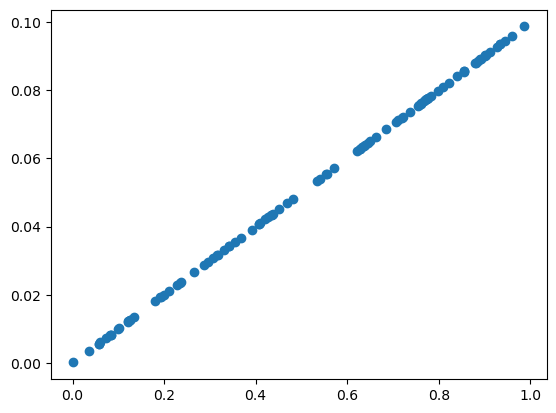

In [3]:
X = np.random.rand(100)
y = 0.2*X*0.5
plt.scatter(X,y)

In [4]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

In [5]:
# 경사하강법 y=wX+b 의 가중치와 편향의 초기값 설정 , w결정
W = np.random.uniform(-1,1) #X의 가중치
b = np.random.uniform(-1,1) #b 편향
learning_rate = 0.5 #임의 값 #학습율

epoch 0, W: 0.5116, Error: 0.7262


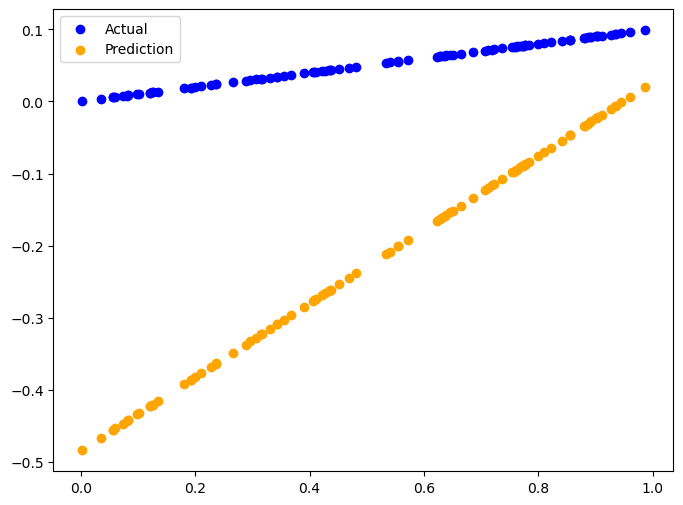

epoch 10, W: 0.4728, Error: 0.0995


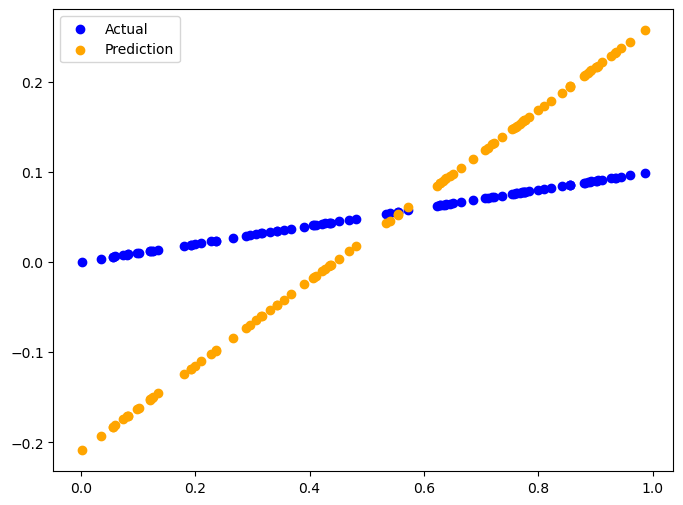

epoch 20, W: 0.3675, Error: 0.0714


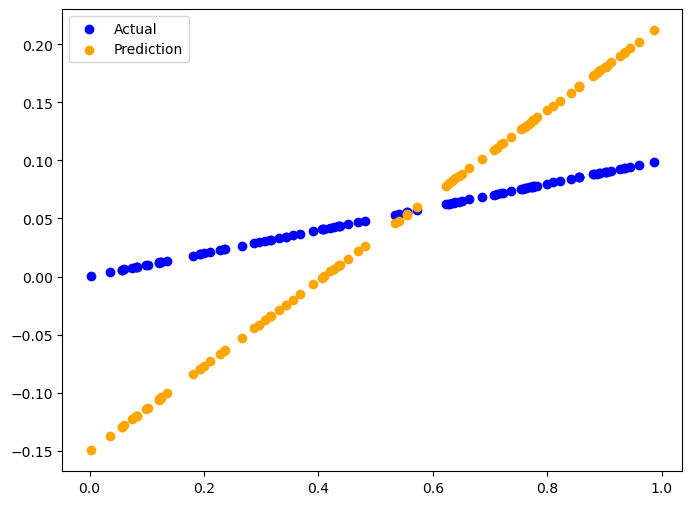

epoch 30, W: 0.2919, Error: 0.0512


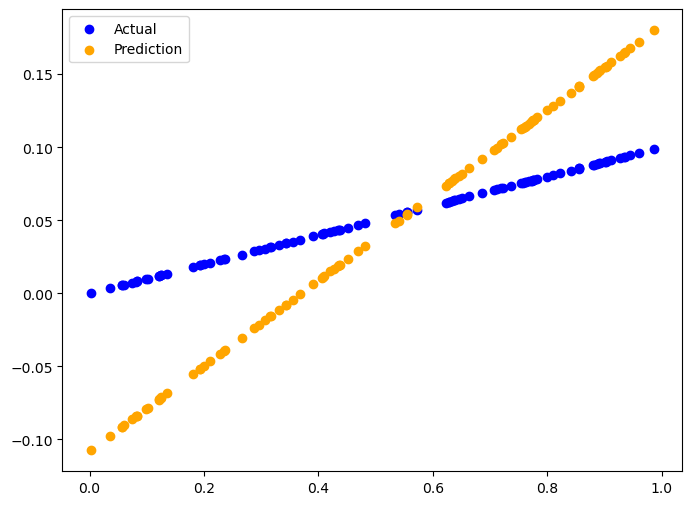

epoch 40, W: 0.2377, Error: 0.0368


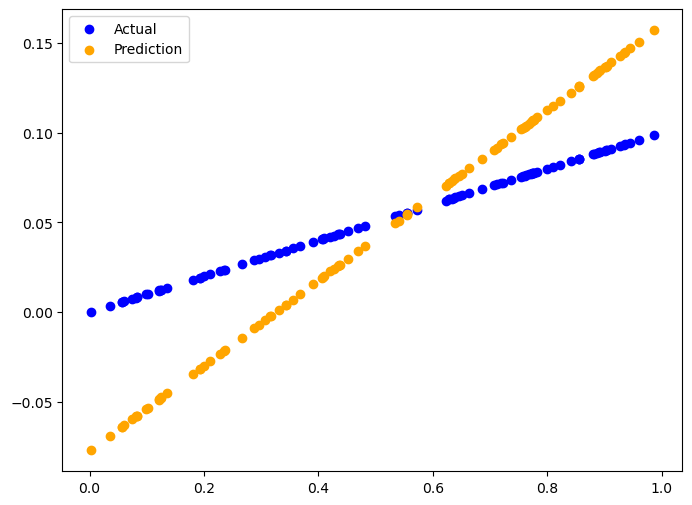

epoch 50, W: 0.1988, Error: 0.0264


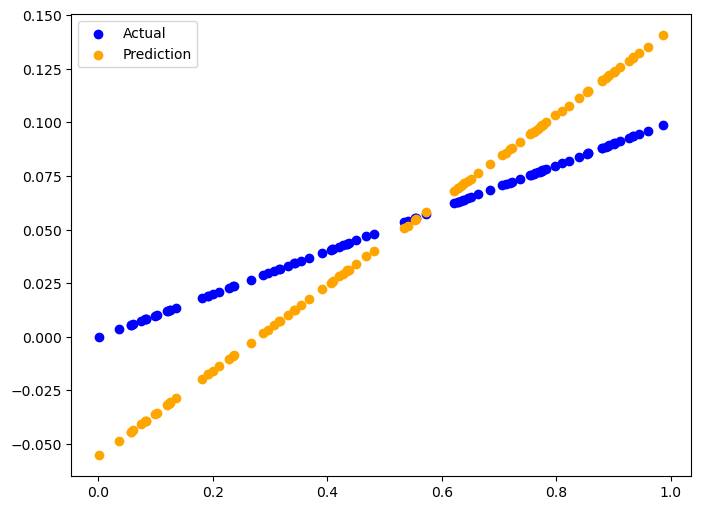

epoch 60, W: 0.1709, Error: 0.0189


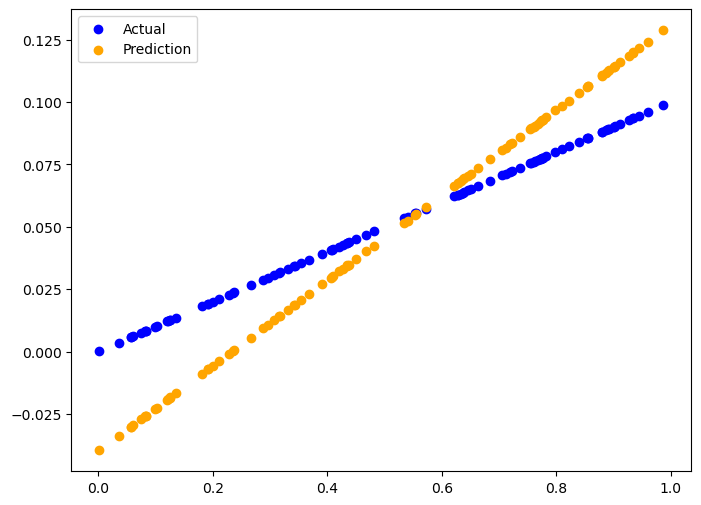

epoch 70, W: 0.1508, Error: 0.0136


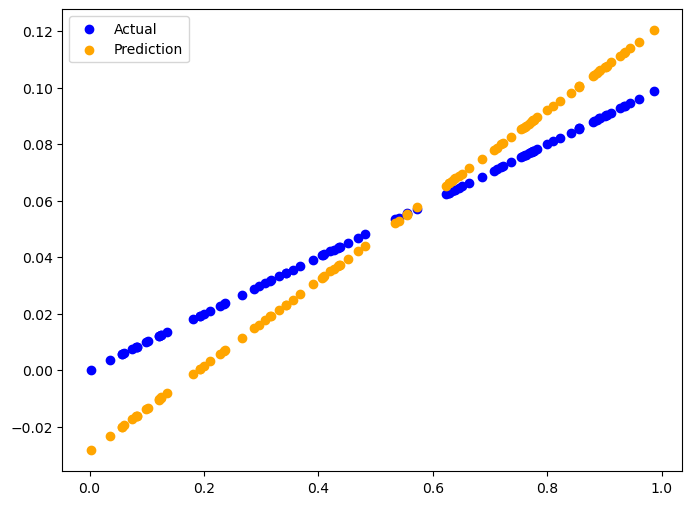

epoch 80, W: 0.1365, Error: 0.0097


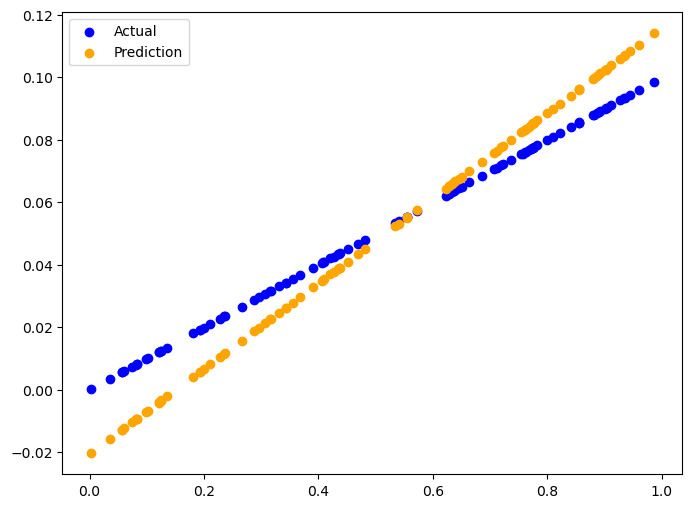

epoch 90, W: 0.1262, Error: 0.0070


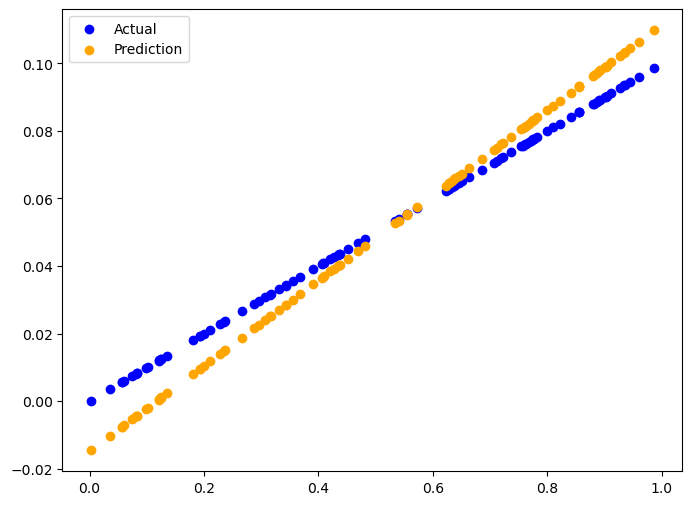

In [6]:
for epoch in range(100):
  y_pred = W * X + b
  error = np.abs(y_pred - y).mean() #평균절대오차 MAE
  if error < 0.001 :
    break
  #경사하강법에 의한 W,b의 조정
  W_descent = learning_rate * ( (y_pred - y)*X).mean()
  b_descent = learning_rate * ( (y_pred - y)).mean()
  W = W - W_descent
  b = b - b_descent
  
  #10epoch마다 시각화
  if epoch%10 == 0 :
    print(f'epoch {epoch}, W: {W:.4f}, Error: {error:.4f}')
    y_pred = W*X + b
    plt_prediction(y_pred, y)

# LinearRegression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [8]:
from sklearn.datasets import fetch_california_housing

In [9]:
house = fetch_california_housing()
house_df = pd.DataFrame(house.data, columns=house.feature_names)
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
#target
house_df['Price'] = house.target
house_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

In [11]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
# 데이터 분할
X = house_df.drop('Price', axis=1).values
y = house_df['Price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, random_state=42)

In [13]:
# LinearRegression 모델
house_lr = LinearRegression()
house_lr.fit(X_train, y_train) #w, b  찾아간다 > 학습 (fit)
y_pred = house_lr.predict(X_test)
y_pred[:10]

array([0.72604907, 1.76743383, 2.71092161, 2.83514727, 2.60695807,
       2.01073856, 2.64067386, 2.16706161, 2.74012056, 3.90361526])

In [14]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(0.7284008391515456), 0.5305677824766759)

In [15]:
r2_score(y_test, y_pred)

0.5957702326061659

In [16]:
house_lr, house_lr.coef_

(LinearRegression(),
 array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
        -7.75740400e-07, -3.37002667e-03, -4.18536747e-01, -4.33687976e-01]))

In [17]:
house_lr.coef_, house_lr.intercept_

(array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
        -7.75740400e-07, -3.37002667e-03, -4.18536747e-01, -4.33687976e-01]),
 np.float64(-37.05624133152509))

In [18]:
pd.Series(data = np.round(house_lr.coef_,1),
          index=house_df.drop('Price', axis=1).columns).sort_values(ascending=False)

AveBedrms     0.8
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

# 다항회귀 모델
- 피처 엔지니어링, 전처리
- 다항회귀, 규제

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [20]:
model_poly = Pipeline( [('poly', PolynomialFeatures(degree=2, include_bias=False)),
           ('linear', LinearRegression())])
model_poly.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [21]:
poly_pred = model_poly.predict(X_test)
mean_squared_error(y_test, poly_pred)

0.4549723374747758

In [22]:
r2_score(y_test, poly_pred)

0.6533650021311979

In [23]:
# ── 1. 2차 / 3차 다항회귀 성능 비교 ──────────────────────────────

degrees = [1, 2, 3]
results = {}

for d in degrees:
    if d == 1:
        model = LinearRegression()
    else:
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('linear', LinearRegression())
        ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    results[f'{d}차'] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"[{d}차 다항회귀]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

results_df = pd.DataFrame(results).T
print()
print(results_df)

[1차 다항회귀]  RMSE: 0.7284  |  R²: 0.5958
[2차 다항회귀]  RMSE: 0.6745  |  R²: 0.6534
[3차 다항회귀]  RMSE: 2.0102  |  R²: -2.0788

         MSE      RMSE        R²
1차  0.530568  0.728401  0.595770
2차  0.454972  0.674516  0.653365
3차  4.041098  2.010248 -2.078838


In [24]:
# ── 2. 결과가 비슷하거나 과적합이 보일 경우 → 규제(Regularization) 적용 ──

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

# 2차 다항 피처 생성 (규제 모델에 공통 사용)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# 스케일링 (Ridge/Lasso는 스케일에 민감)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled  = scaler.transform(X_test_poly)

reg_models = {
    'Ridge (L2)'   : Ridge(alpha=1.0),
    'Lasso (L1)'   : Lasso(alpha=0.001),
    'ElasticNet'   : ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print("=== 규제 모델 비교 (2차 다항 피처 기반) ===")
reg_results = {}

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    reg_results[name] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"[{name}]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

reg_results_df = pd.DataFrame(reg_results).T
print()
print(reg_results_df)

=== 규제 모델 비교 (2차 다항 피처 기반) ===
[Ridge (L2)]  RMSE: 0.6751  |  R²: 0.6528


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.902e+02, tolerance: 1.936e+00
  model = cd_fast.enet_coordinate_descent(


[Lasso (L1)]  RMSE: 0.6906  |  R²: 0.6366
[ElasticNet]  RMSE: 0.6909  |  R²: 0.6363

                 MSE      RMSE        R²
Ridge (L2)  0.455742  0.675087  0.652779
Lasso (L1)  0.476967  0.690628  0.636608
ElasticNet  0.477380  0.690927  0.636293


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.545e+03, tolerance: 1.936e+00
  model = cd_fast.enet_coordinate_descent(


# Ridge 회귀

In [25]:
from sklearn.linear_model import Ridge

# 3. 릿지 회귀
ridge = Ridge(alpha=1.0)  # alpha는 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("\n[릿지 회귀]")
print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))


[릿지 회귀]
MSE: 0.5305052690933699
R2: 0.5958178603951636


# Lasso 회귀

In [26]:
from sklearn.linear_model import Lasso
# 4. 라쏘 회귀

lasso = Lasso(alpha=0.1)  # alpha 값 작으면 규제 약해짐
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\n[라쏘 회귀]")
print("MSE:", mean_squared_error(y_test, pred_lasso))
print("R2:", r2_score(y_test, pred_lasso))


[라쏘 회귀]
MSE: 0.5970512258509185
R2: 0.5451177283676661


# Elastic Net 회귀.

In [27]:
# 5. 엘라스틱넷 회귀
model_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5: L1과 L2의 비중 50:50
model_enet.fit(X_train, y_train)
pred_enet = model_enet.predict(X_test)

print("\n[엘라스틱넷 회귀]")
print("MSE:", mean_squared_error(y_test, pred_enet))
print("R2:", r2_score(y_test, pred_enet))


[엘라스틱넷 회귀]
MSE: 0.5571449056777037
R2: 0.5755216146456115


# 자전거 대여 예측 [회귀]

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv(r'C:\Users\Admin\hipython\data\bike_train.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [29]:
print('=== 기본 정보 ===')
print(df.info())
print()
print('=== 기술 통계 ===')
display(df.describe())
print()
print('=== 결측치 ===')
print(df.isnull().sum())

=== 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
None

=== 기술 통계 ===


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000



=== 결측치 ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [30]:
# datetime → 파생 변수 추출
df['datetime'] = pd.to_datetime(df['datetime'])
df['year']     = df['datetime'].dt.year
df['month']    = df['datetime'].dt.month
df['hour']     = df['datetime'].dt.hour
df['dayofweek']= df['datetime'].dt.dayofweek

# 모델에 사용할 피처 선택 (datetime, casual, registered 제외)
feature_cols = ['season','holiday','workingday','weather',
                'temp','atemp','humidity','windspeed',
                'year','month','hour','dayofweek']

X = df[feature_cols].values
y = df['count'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('피처 목록:', feature_cols)

X shape: (10886, 12)
y shape: (10886,)
피처 목록: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '  X_test:', X_test.shape)

def evaluate(model_name, y_test, y_pred):
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f'[ {model_name} ]')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print('-' * 35)
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

all_results = []   # 최종 비교용

X_train: (8708, 12)   X_test: (2178, 12)


# 단순회귀 모델

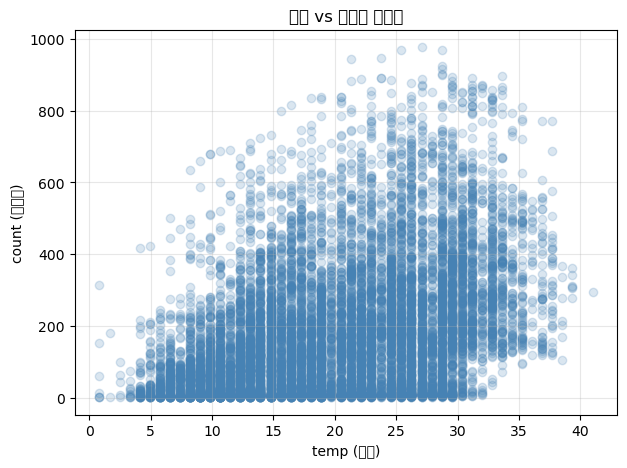

In [33]:
# 단순 회귀 모델
# 대표 단일 피처 1개만 사용: temp(기온) → count(대여량)

X_simple = df['temp'].values
y_simple  = df['count'].values

# 산점도 확인
plt.figure(figsize=(7, 5))
plt.scatter(X_simple, y_simple, alpha=0.2, color='steelblue')
plt.xlabel('temp (기온)')
plt.ylabel('count (대여량)')
plt.title('기온 vs 자전거 대여량')
plt.grid(alpha=0.3)
plt.show()

epoch   0  |  W: 45.0699  |  RMSE: 267.2287
epoch  40  |  W: 2094670626258242863366144.0000  |  RMSE: 12267395860422332472360960.0000
epoch  80  |  W: 122917079705958964081568558929052266568035074048.0000  |  RMSE: 719861373839776199989913038713259416731296727040.0000
epoch 120  |  W: 7212880294421230738534216774128718780843125032458164269452634475200512.0000  |  RMSE: 42242086539192293068399091746094017761542208495685248603382074761543680.0000
epoch 160  |  W: 423258039209078701573019116871645771471119940221279978101232133122787956292998007505784143872.0000  |  RMSE: 2478802086110789492988347420507050931799453210262297507752532832576711500142970618380111839232.0000

최종  W: -6697138715875448391608392060916561098647973351116419333299961202964937080175909937095809438840110228592492739035136.0000,  b: -288358828313288830435227621745026748262989162841565368521820028631519175580649537202669205051200280423178595991552.0000,  RMSE: 3922165648857287141517952345291832848970563199370514401451446

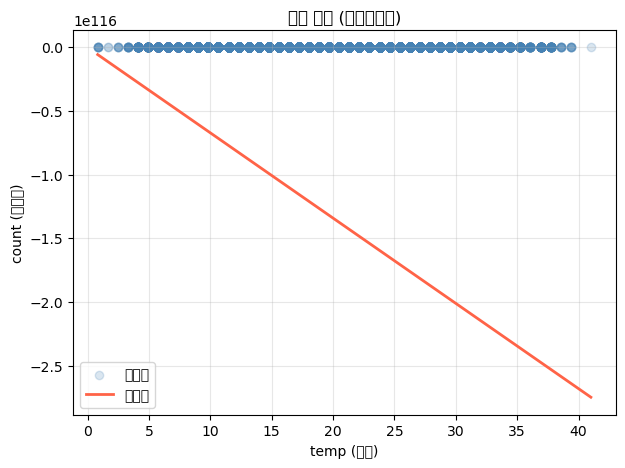

In [34]:
# 경사하강법으로 단순회귀 직접 학습 (y = W*x + b)

np.random.seed(42)
W = np.random.uniform(-1, 1)
b = np.random.uniform(-1, 1)
learning_rate = 0.01

for epoch in range(200):
    y_pred_s = W * X_simple + b
    error    = np.sqrt(np.mean((y_pred_s - y_simple) ** 2))   # RMSE

    if error < 1.0:
        break

    W -= learning_rate * ((y_pred_s - y_simple) * X_simple).mean()
    b -= learning_rate * ((y_pred_s - y_simple)).mean()

    if epoch % 40 == 0:
        print(f'epoch {epoch:3d}  |  W: {W:.4f}  |  RMSE: {error:.4f}')

print(f'\n최종  W: {W:.4f},  b: {b:.4f},  RMSE: {error:.4f}')

# 결과 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X_simple, y_simple, alpha=0.2, color='steelblue', label='실제값')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
plt.plot(x_line, W * x_line + b, color='tomato', linewidth=2, label='예측선')
plt.xlabel('temp (기온)')
plt.ylabel('count (대여량)')
plt.title('단순 회귀 (경사하강법)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# LinearRegression 다중선형회귀

In [35]:
# LinearRegression (다중 선형 회귀)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

all_results.append(evaluate('LinearRegression', y_test, lr_pred))

# 피처 중요도 (계수)
coef_df = pd.Series(
    np.round(lr.coef_, 2),
    index=feature_cols
).sort_values(ascending=False)

print('\n피처별 계수:')
print(coef_df)

[ LinearRegression ]
  MSE  : 19952.5782
  RMSE : 141.2536
  R²   : 0.3955
-----------------------------------

피처별 계수:
year          82.69
month         10.18
hour           7.86
atemp          5.03
workingday     3.05
temp           1.15
dayofweek      0.66
windspeed      0.55
humidity      -2.03
weather       -5.19
holiday       -5.45
season        -8.16
dtype: float64


# 다항회귀 모델

In [36]:
# 다항 회귀 모델 (Polynomial Regression)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

degrees = [1, 2, 3]
poly_results = {}

print('=== 다항 회귀 비교 ===')
for d in degrees:
    if d == 1:
        model = LinearRegression()
    else:
        model = Pipeline([
            ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
            ('linear', LinearRegression())
        ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    poly_results[f'{d}차'] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f'[{d}차 다항회귀]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}')

print()
print(pd.DataFrame(poly_results).T.round(4))

=== 다항 회귀 비교 ===
[1차 다항회귀]  RMSE: 141.2536  |  R²: 0.3955
[2차 다항회귀]  RMSE: 120.3727  |  R²: 0.5610
[3차 다항회귀]  RMSE: 110.6068  |  R²: 0.6294

           MSE      RMSE      R²
1차  19952.5782  141.2536  0.3955
2차  14489.5818  120.3727  0.5610
3차  12233.8533  110.6068  0.6294


# 2차 다항 피처

In [37]:
# 2차 다항 피처 + StandardScaler (규제 모델 공통 전처리)
from sklearn.preprocessing import StandardScaler

poly2  = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

X_train_poly   = poly2.fit_transform(X_train)
X_test_poly    = poly2.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled  = scaler.transform(X_test_poly)

print('2차 다항 피처 수:', X_train_poly.shape[1])
print('스케일링 완료 → shape:', X_train_scaled.shape)

2차 다항 피처 수: 90
스케일링 완료 → shape: (8708, 90)


# Ridge 회귀

In [38]:
# Ridge 회귀 (L2 규제)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

result_ridge = evaluate('Ridge (L2)', y_test, ridge_pred)
all_results.append(result_ridge)

[ Ridge (L2) ]
  MSE  : 14906.4179
  RMSE : 122.0918
  R²   : 0.5484
-----------------------------------


# Lasso 회귀

In [39]:
# Lasso 회귀 (L1 규제)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

result_lasso = evaluate('Lasso (L1)', y_test, lasso_pred)
all_results.append(result_lasso)

# Lasso가 0으로 만든 피처 수 확인
zero_coef = np.sum(lasso.coef_ == 0)
print(f'  계수가 0인 피처 수 (제거된 피처): {zero_coef}개')

[ Lasso (L1) ]
  MSE  : 15005.3437
  RMSE : 122.4963
  R²   : 0.5454
-----------------------------------
  계수가 0인 피처 수 (제거된 피처): 26개


# Elastic Net 회귀

In [40]:
# Elastic Net 회귀 (L1 + L2 혼합 규제)
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
enet.fit(X_train_scaled, y_train)
enet_pred = enet.predict(X_test_scaled)

result_enet = evaluate('ElasticNet', y_test, enet_pred)
all_results.append(result_enet)

[ ElasticNet ]
  MSE  : 16283.5011
  RMSE : 127.6068
  R²   : 0.5067
-----------------------------------


# 전체 모델 성능 비교

=== 전체 모델 성능 비교 (RMSE 오름차순) ===


,MSE,RMSE,R²
model,,,
Ridge (L2),14906.4179,122.0918,0.5484
Lasso (L1),15005.3437,122.4963,0.5454
ElasticNet,16283.5011,127.6068,0.5067
LinearRegression,19952.5782,141.2536,0.3955



🏆 최저 RMSE 모델: Ridge (L2)  (RMSE: 122.0918)


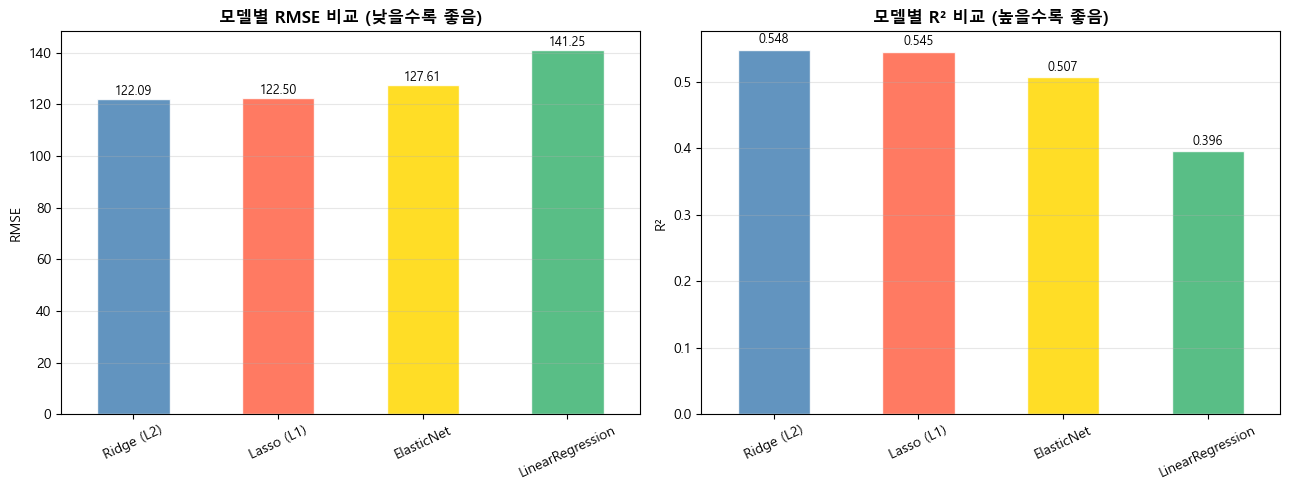

In [41]:
# 전체 모델 성능 비교
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac 한글
matplotlib.rcParams['axes.unicode_minus'] = False

summary_df = pd.DataFrame(all_results).set_index('model')
summary_df = summary_df.sort_values('RMSE')

print('=== 전체 모델 성능 비교 (RMSE 오름차순) ===')
display(
    summary_df.style
    .highlight_min(subset=['MSE', 'RMSE'], axis=0, color='lightgreen')
    .highlight_max(subset=['R²'],          axis=0, color='lightgreen')
    .format({'MSE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}'})
)

best = summary_df['RMSE'].idxmin()
print(f'\n🏆 최저 RMSE 모델: {best}  (RMSE: {summary_df.loc[best, "RMSE"]:.4f})')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

summary_df['RMSE'].plot(kind='bar', ax=axes[0],
    color=['steelblue','tomato','gold','mediumseagreen'],
    edgecolor='white', alpha=0.85)
axes[0].set_title('모델별 RMSE 비교 (낮을수록 좋음)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.3)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=9)

summary_df['R²'].plot(kind='bar', ax=axes[1],
    color=['steelblue','tomato','gold','mediumseagreen'],
    edgecolor='white', alpha=0.85)
axes[1].set_title('모델별 R² 비교 (높을수록 좋음)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.3)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()